## Setup

In [1]:
from gut_former.utils.fig_style import apply_style

apply_style(font_family="DejaVu Serif", base_font_size=16)

In [2]:
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    auc, roc_curve, precision_score, recall_score, f1_score,
)

In [3]:
from gut_former.utils.project_paths import find_data_path, find_figures_path

data_path = find_data_path()
output_path = find_data_path().parent / "output"
figures_path = find_figures_path()
figures_path.mkdir(parents=True, exist_ok=True)

## Read Data

In [4]:
latent_df = pd.read_csv(f"{output_path}/latent_sample.csv", index_col=0)

metadata = (
    pd.read_csv(f"{data_path}/metadata_sample.csv", low_memory=False)
    .query("sample_id in @latent_df.index")
    .sort_index()
)
metadata["health_status"] = (metadata["study_condition"] != "control").astype(int)

study_condition_dict = dict(zip(metadata.sample_id, metadata.study_condition))
health_status_dict   = dict(zip(metadata.sample_id, metadata.health_status))

print(f"latent: {latent_df.shape}")
print(latent_df.index.map(study_condition_dict).value_counts().to_dict())

latent: (128, 64)
{'control': 74, 'AS': 52, 'CRC': 2}


/var/folders/6p/lf2mjrln3bn2l0f1tywc4j580000gn/T/ipykernel_24993/649099768.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  metadata["health_status"] = (metadata["study_condition"] != "control").astype(int)


In [5]:
# Conditions with enough samples for binary classification (control kept for reference)
disease_counts = latent_df.index.map(study_condition_dict).value_counts()
keep_diseases = [d for d in disease_counts[disease_counts > 15].index if d not in ["FMT", "BD"]]

palette = sns.color_palette("hls", len(keep_diseases))
disease_cmap = dict(zip(keep_diseases, palette.as_hex()))

# Short codes for compact axis labels
disease_shortcut_dict = {
    "TKI_dependent_diarrhoea": "TKI", "acute_diarrhoea": "ACD", "adenoma": "ADM",
    "asthma": "ASTM", "cephalosporins": "CEPH", "cirrhosis": "CIRR", "fatty_liver": "FL",
    "melanoma": "MLNM", "migraine": "MGR", "otitis": "OTS", "premature_born": "PB",
    "carcinoma_surgery_history": "CSH", "ACVD": "ACVD", "BD": "BD", "CAD": "CAD",
    "CDI": "CDI", "CRC": "CRC", "HF": "HF", "IBD": "IBD", "IGT": "IGT", "ME/CFS": "ME/CFS",
    "PD": "PD", "STEC": "STEC", "STH": "STH", "T1D": "T1D", "T2D": "T2D",
}


def short_name(series):
    # GUARD (G1): map to a short code but fall back to the original name when the
    # condition is not in the lookup. A hard .map() turns unlisted conditions
    # (e.g. AS, control) into NaN, which blanks axis labels and - via the later
    # dropna() - silently drops every row, leaving an empty plot.
    return series.map(lambda d: disease_shortcut_dict.get(d, d))

# Supplementary Figure 4A - disease distribution

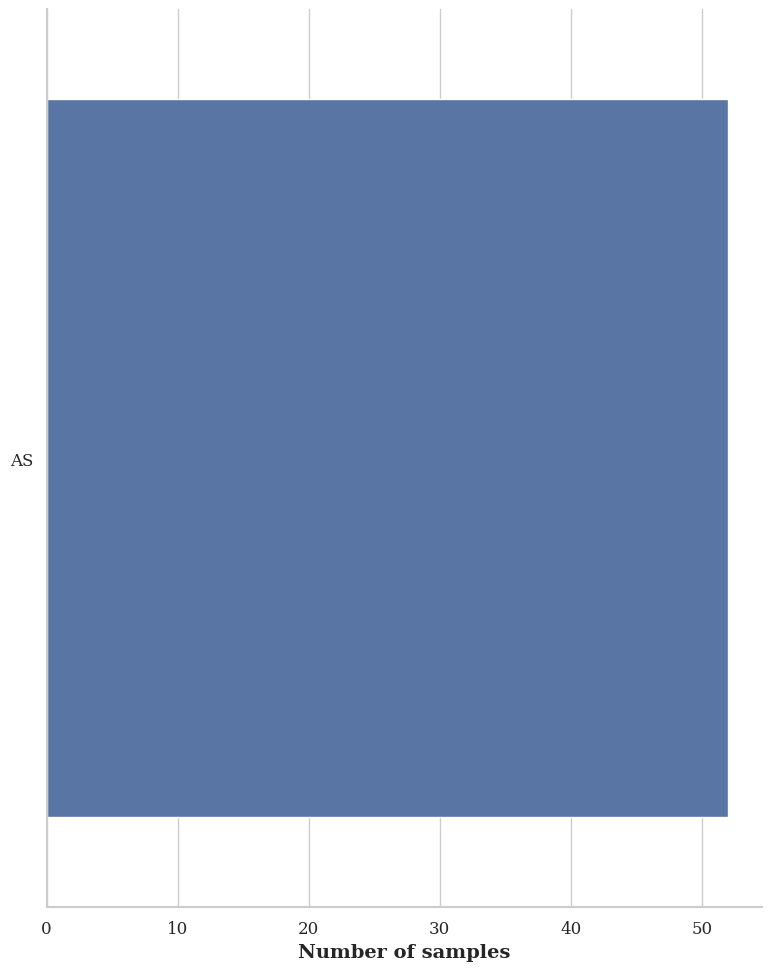

In [6]:
plot_disease = [d for d in keep_diseases if d != "control"]

if not plot_disease:
    # GUARD (G4): nothing to show if no non-control condition clears the threshold.
    print("No qualifying disease - skipping sFig4A.")
else:
    counts = (pd.Series(Counter(d for d in latent_df.index.map(study_condition_dict)
                                if d in plot_disease))
              .sort_values(ascending=False))
    plt.figure(figsize=(8, 10))
    sns.barplot(y=counts.index, x=counts.values, color="#4c72b0")
    sns.despine()
    plt.xlabel("Number of samples", fontsize=14, fontweight="bold")
    plt.ylabel("")
    plt.tight_layout()
    plt.savefig(f"{figures_path}/sFig4A.png", dpi=300, bbox_inches="tight")
    plt.show()

# Figure 4A - binary classification ROC (disease vs control)

In [7]:
input_data = latent_df.copy()
input_data["study_condition"] = latent_df.index.map(study_condition_dict)
input_data["health_status"] = latent_df.index.map(health_status_dict)

diseases_to_classify = [d for d in keep_diseases if d != "control"]

param_grid = {"n_estimators": [100, 300], "max_depth": [None, 10, 20]}
FOLD_RESULTS, ROC_RESULTS = [], []

# GUARD (G4): nothing to classify if no condition clears the N>15 threshold.
# Bail out early (like the country panel in figure3) instead of building empty
# result frames that break the plotting code below.
if not diseases_to_classify:
    print("No disease clears the N>15 threshold - skipping Fig4A/B.")

for disease in diseases_to_classify:
    disease_df = input_data.query("study_condition == @disease")
    try:
        control_df = (input_data.query("study_condition == 'control'")
                      .sample(disease_df.shape[0], random_state=42))
    except ValueError:
        control_df = input_data.query("study_condition == 'control'")

    combined = pd.concat([disease_df, control_df])
    X = combined.iloc[:, :64]
    y = combined["health_status"]

    # GUARD (G5): cap CV folds at the smallest class size. StratifiedKFold requires
    # n_splits <= the rarest class count; hardcoding 5 folds crashes on small or
    # imbalanced cohorts.
    n_splits = min(5, y.value_counts().min())
    if n_splits < 2:
        print(f"{disease}: too few samples for CV - skipping.")
        continue
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    for fold, (tr, te) in enumerate(skf.split(X, y), start=1):
        X_tr, X_te, y_tr, y_te = X.iloc[tr], X.iloc[te], y.iloc[tr], y.iloc[te]
        scaler = StandardScaler().fit(X_tr)
        gs = GridSearchCV(RandomForestClassifier(random_state=42), param_grid,
                          cv=3, scoring="roc_auc", n_jobs=-1)
        gs.fit(scaler.transform(X_tr), y_tr)
        rf = gs.best_estimator_
        proba = rf.predict_proba(scaler.transform(X_te))[:, 1]
        pred = rf.predict(scaler.transform(X_te))
        fpr, tpr, _ = roc_curve(y_te, proba)
        roc_auc = auc(fpr, tpr)
        ROC_RESULTS.append({"disease": disease, "fold": fold, "fpr": fpr, "tpr": tpr, "auc": roc_auc})
        FOLD_RESULTS.append({"disease": disease, "fold": fold,
                             "precision": precision_score(y_te, pred, zero_division=np.nan),
                             "recall": recall_score(y_te, pred),
                             "auc": roc_auc, "f1": f1_score(y_te, pred)})

FOLD_RESULTS_DF = pd.DataFrame(FOLD_RESULTS)
ROC_RESULTS_DF = pd.DataFrame(ROC_RESULTS)

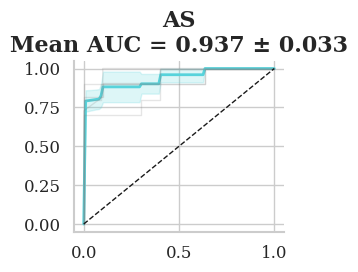

In [8]:
def plot_mean_roc_per_disease(roc_data, n_cols=4):
    diseases = roc_data.sort_values("auc", ascending=False)["disease"].unique()
    n_rows = int(np.ceil(len(diseases) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))
    # GUARD (G3): always normalise `axes` to a flat 1-D array. plt.subplots() returns
    # an ndarray whose shape depends on n_rows/n_cols; the original `[axes]` fallback
    # wrapped the whole array for a single disease, so axes[0] was the array (not an
    # Axes) and ax.plot() crashed.
    axes = np.atleast_1d(axes).ravel()

    mean_fpr = np.linspace(0, 1, 100)
    for idx, disease in enumerate(diseases):
        ax = axes[idx]
        d = roc_data[roc_data["disease"] == disease]
        tprs = [np.interp(mean_fpr, r["fpr"], r["tpr"]) for _, r in d.iterrows()]
        for t in tprs:
            t[0] = 0.0
        mean_tpr, std_tpr = np.mean(tprs, axis=0), np.std(tprs, axis=0)
        ax.plot(mean_fpr, mean_tpr, color=disease_cmap[disease], linewidth=2)
        ax.fill_between(mean_fpr, np.maximum(mean_tpr - std_tpr, 0),
                        np.minimum(mean_tpr + std_tpr, 1), color=disease_cmap[disease], alpha=0.2)
        for _, r in d.iterrows():
            ax.plot(r["fpr"], r["tpr"], "gray", alpha=0.2, linewidth=1)
        ax.plot([0, 1], [0, 1], "k--", lw=1)
        ax.set_title(f"{disease}\nMean AUC = {d['auc'].mean():.3f} ± {d['auc'].std():.3f}", weight="bold")
        ax.spines[["top", "right"]].set_visible(False)

    for idx in range(len(diseases), len(axes)):
        axes[idx].set_visible(False)
    plt.tight_layout()
    return fig


if not ROC_RESULTS_DF.empty:
    fig = plot_mean_roc_per_disease(ROC_RESULTS_DF, n_cols=min(4, ROC_RESULTS_DF["disease"].nunique()))
    fig.savefig(f"{figures_path}/Fig4A.png", dpi=300, bbox_inches="tight")
    plt.show()

# Figure 4B - binary precision / recall

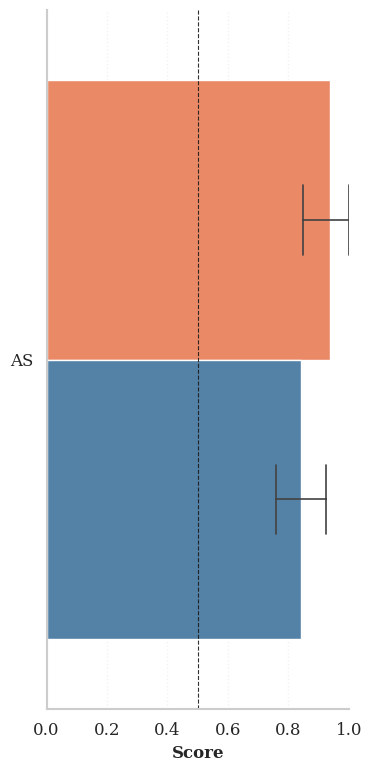

In [9]:
if not FOLD_RESULTS_DF.empty:
    # pandas 3.0: use melt (stack column naming changed); long-form precision/recall
    pr_df = (FOLD_RESULTS_DF[["disease", "precision", "recall"]]
             .melt(id_vars="disease", var_name="Metric", value_name="Score")
             .sort_values("disease"))
    pr_df["disease"] = short_name(pr_df["disease"])  # GUARD (G1)

    fig, ax = plt.subplots(figsize=(4, 8))
    sns.barplot(data=pr_df, y="disease", x="Score", hue="Metric",
                palette={"precision": "coral", "recall": "steelblue"},
                capsize=0.2, legend=False, err_kws={"linewidth": 1.2}, ax=ax)
    ax.axvline(0.5, color="k", linestyle="--", linewidth=0.8, alpha=0.9)
    ax.set_xlim(0, 1)
    ax.set_xlabel("Score", fontsize=12, weight="bold")
    ax.set_ylabel("")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", alpha=0.25, linestyle=":")
    plt.tight_layout()
    plt.savefig(f"{figures_path}/Fig4B.png", dpi=300, bbox_inches="tight")
    plt.show()

# Figure 4C - multiclass classification ROC

In [10]:
# Multiclass: conditions with N>30
disease_counts = latent_df.index.map(study_condition_dict).value_counts()
keep_diseases_mc = [d for d in disease_counts[disease_counts > 30].index if d not in ["FMT", "BD"]]

# GUARD (G2): the multiclass ROC needs >=3 classes. With only 2, label_binarize()
# collapses to a single column (sklearn's binary convention), so the per-class loop
# would index a non-existent column and crash. Skip multiclass with a message when
# fewer than 3 conditions clear the sample-count threshold.
RUN_MULTICLASS = len(keep_diseases_mc) >= 3
MC_FOLD_DF, MC_ROC_DF = pd.DataFrame(), pd.DataFrame()

if not RUN_MULTICLASS:
    print(f"Only {len(keep_diseases_mc)} classes qualify (N>30): {keep_diseases_mc} "
          f"- skipping multiclass (Fig4C/D).")
else:
    mc = input_data[input_data["study_condition"].isin(keep_diseases_mc)].copy()
    min_n = mc["study_condition"].value_counts().min()
    # pandas 3.0: groupby.apply drops the grouping column; use groupby.sample which
    # keeps all columns and samples per group.
    mc = mc.groupby("study_condition", group_keys=False).sample(min_n, random_state=42)

    X, y = mc.iloc[:, :64], mc["study_condition"]
    param_grid = {"n_estimators": [100, 300], "max_depth": [None, 10, 20], "min_samples_split": [2, 5]}
    n_splits = min(5, y.value_counts().min())  # GUARD (G5)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    fold_res, roc_res = [], []
    for fold, (tr, te) in enumerate(skf.split(X, y), start=1):
        X_tr, X_te, y_tr, y_te = X.iloc[tr], X.iloc[te], y.iloc[tr], y.iloc[te]
        scaler = StandardScaler().fit(X_tr)
        gs = GridSearchCV(RandomForestClassifier(random_state=42, class_weight="balanced"),
                          param_grid, cv=3, scoring="f1_macro", n_jobs=-1)
        gs.fit(scaler.transform(X_tr), y_tr)
        rf = gs.best_estimator_
        proba = rf.predict_proba(scaler.transform(X_te))
        pred = rf.predict(scaler.transform(X_te))
        y_bin = label_binarize(y_te, classes=rf.classes_)
        prec = precision_score(y_te, pred, labels=rf.classes_, average=None, zero_division=np.nan)
        rec = recall_score(y_te, pred, labels=rf.classes_, average=None)
        f1 = f1_score(y_te, pred, labels=rf.classes_, average=None)
        for i, cls in enumerate(rf.classes_):
            fpr, tpr, _ = roc_curve(y_bin[:, i], proba[:, i])
            roc_res.append({"disease": cls, "fold": fold, "fpr": fpr, "tpr": tpr, "auc": auc(fpr, tpr)})
            fold_res.append({"disease": cls, "fold": fold, "precision": prec[i],
                             "recall": rec[i], "auc": auc(fpr, tpr), "f1": f1[i]})
    MC_FOLD_DF, MC_ROC_DF = pd.DataFrame(fold_res), pd.DataFrame(roc_res)
    print("Multiclass done:", mc["study_condition"].value_counts().to_dict())

Only 2 classes qualify (N>30): ['control', 'AS'] - skipping multiclass (Fig4C/D).


In [11]:
if RUN_MULTICLASS and not MC_ROC_DF.empty:
    roc = MC_ROC_DF.copy()
    roc["disease"] = short_name(roc["disease"])  # GUARD (G1)
    mean_fpr = np.linspace(0, 1, 100)
    colors = plt.cm.tab20(np.linspace(0, 1, roc["disease"].nunique()))

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Chance")
    for disease, color in zip(roc["disease"].unique(), colors):
        d = roc[roc["disease"] == disease]
        tprs = [np.interp(mean_fpr, r["fpr"], r["tpr"]) for _, r in d.iterrows()]
        mean_tpr = np.mean(tprs, axis=0)
        mean_tpr[0] = 0.0
        ax.plot(mean_fpr, mean_tpr, color=color, lw=2,
                label=f"{disease} (AUC = {d['auc'].mean():.2f} ± {d['auc'].std():.2f})")
    ax.set_xlabel("False Positive Rate", fontsize=16, weight="bold")
    ax.set_ylabel("True Positive Rate", fontsize=16, weight="bold")
    ax.legend(loc="lower right", fontsize=11, ncol=2, edgecolor="w")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig(f"{figures_path}/Fig4C.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Multiclass skipped - no Fig4C.")

Multiclass skipped - no Fig4C.


# Figure 4D - multiclass precision / recall

In [12]:
if RUN_MULTICLASS and not MC_FOLD_DF.empty:
    pr_df = (MC_FOLD_DF[["disease", "precision", "recall"]]
             .melt(id_vars="disease", var_name="Metric", value_name="Score")
             .sort_values("disease"))
    pr_df["disease"] = short_name(pr_df["disease"])  # GUARD (G1)

    diseases = pr_df["disease"].unique()
    first_batch = diseases[:9]
    subsets = [pr_df[pr_df["disease"].isin(first_batch)],
               pr_df[~pr_df["disease"].isin(first_batch)]]
    subsets = [s for s in subsets if not s.empty]  # GUARD: drop empty row when <=9 classes

    fig, axes = plt.subplots(len(subsets), 1, figsize=(8, 3 * len(subsets)), squeeze=False)
    for ax, subset in zip(axes.ravel(), subsets):
        sns.barplot(data=subset, x="disease", y="Score", hue="Metric",
                    palette={"precision": "coral", "recall": "steelblue"},
                    capsize=0.15, err_kws={"linewidth": 1.2, "color": "#333333"},
                    legend=False, ax=ax)
        ax.set_ylim(0, 1.05)
        ax.set_xlabel(""); ax.set_ylabel("")
        ax.spines[["top", "right"]].set_visible(False)
        ax.axhline(0.5, color="k", linestyle="--", linewidth=0.9, alpha=0.8)
    fig.text(-0.01, 0.5, "score", va="center", rotation="vertical", fontsize=16, weight="bold")
    plt.tight_layout()
    plt.savefig(f"{figures_path}/Fig4D.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Multiclass skipped - no Fig4D.")

Multiclass skipped - no Fig4D.
